### **Description**

Recipe showing how to use annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using bias-corrected ERA-5 atmospheric forcing (1976-present) to create a virtual NEMODataTree and serialize to a local Icechunk repository.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**

Rather that having to merge *O*(100) - *O*(1000s) of netCDF files to create a `NEMODataTree` at the begining of every analysis script, we can build a virtual `NEMODataTree` once and then serialize this to disk using a local Icechunk repository.

We can think of a virtual `NEMODataTree` as a lightweight, persistent map describing how to organise our netCDF files into a `NEMODataTree`. When we save this virtual `NEMODataTree` to an Icechunk repository, we effectively create a virtual catalogue of our existing NEMO outputs. The repository stores the `NEMODataTree` structure, coordinates, and references to every chunk of data in the original NetCDF files, but it *does not duplicate* the model output itself. The NetCDF files remain where they are on disk, while the Icechunk repository provides a consolidated view of the simulation that can be opened with xarray as if it were a single Zarr store.

Here, we show how to construct a virtual `NEMODataTree` from the 1° NOC Near-Present-Day global ocean sea-ice hindcast, serialize this to a local Icechunk repository, and then open this repository as a `NEMODataTree` using the `from_icechunk()` constructor.

---

In [12]:
# -- Import required packages -- #
import cartopy.crs as ccrs
import icechunk

from nemo_cookbook import NEMODataTree

### **Using Dask**

---

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1 ERA5v1, if we wanted to generalise this recipe to eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/',
                     'local_directory': '/dssgfs01/working/otooth/Diagnostics/nemo_cookbook/recipes/'
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=5, threads_per_worker=2, memory_limit='4GB')
client = Client(cluster)
client

##### **Creating a Virtual NEMODataTree from Local Files**

* We can create a virtual `NEMODataTree` from a dictionary of paths to local netCDF files using the `.virtualize_from_paths()` constructor:

---

`virtualize_from_paths()`

* Creates a virtual `NEMODataTree` from a dictionary of paths to NEMO model outputs files organised into a hierarchy (e.g., `parent`, `child` `grandchild`) of NEMO model grids (e.g., `gridT`, `gridU`, etc.):
```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where the `gridT` node contains time series of scalar variables stored in the `...grid_T.nc` files in a single `xarray.Dataset` and so on.

---

* Let's start by defining the `paths` dictionary, which contains the filepaths corresponding to the annual mean outputs for our global parent domain (2020-2026).

* We populate the `parent` dictionary with the filepaths to the `domain_cfg` and `gridT/U/V/W` netCDF files produced for the eORCA1 ERA5v1 global parent domain. 

In [2]:
# Define prefix / directory containing NEMO model domain_cfg and output files:
prefix = "/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1"

# Define paths dict for global parent domain only:
paths = {"parent": {
         "domain": f"{prefix}/eORCA1_ERA5v1_domain_cfg_mesh_mask.nc",
         "gridT": f"{prefix}/eORCA1_ERA5_1y_grid_T_202*.nc",
         "gridU": f"{prefix}/eORCA1_ERA5_1y_grid_U_202*.nc",
         "gridV": f"{prefix}/eORCA1_ERA5_1y_grid_V_202*.nc",
         "gridW": f"{prefix}/eORCA1_ERA5_1y_grid_W_202*.nc",
         "icemod": f"{prefix}/eORCA1_ERA5_1y_icemod_202*.nc"
        },
        }

paths

{'parent': {'domain': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5v1_domain_cfg_mesh_mask.nc',
  'gridT': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1y_grid_T_202*.nc',
  'gridU': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1y_grid_U_202*.nc',
  'gridV': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1y_grid_V_202*.nc',
  'gridW': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1y_grid_W_202*.nc',
  'icemod': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1y_icemod_202*.nc'}}

* We can now construct a new virtual `NEMODataTree` using the `.virtualize_from_paths()` constructor.

* We also need to specify that our global parent domain is zonally periodic (`iperio=True`) and north folding on F-points (`nftype = "F"`) rather than a closed (regional) domain.

In [3]:
# Create virtual NEMODataTree from paths:
nemo = NEMODataTree.virtualize_from_paths(prefix=prefix,
                                                        paths=paths,
                                                        loadable_vars=["axis_nbounds"],
                                                        name="eORCA1 ERA5v1",
                                                        iperio=True,
                                                        nftype="F",
                                                        )

nemo

/dssgfs01/working/otooth/Software/nemo_cookbook/nemo_cookbook/virtualize.py:281: UserWarning: Dropping invalid variables ['ficeberg', 'berg_latent_heat_flux', 'empmr', 'sohflisf', 'sohfcisf', 'sowflisf'] found in file: 'eORCA1_ERA5_1y_grid_T_2020-2020.nc'
  invalid_vars = _get_invalid_vars(filepath=filepaths[0])
/dssgfs01/working/otooth/Software/nemo_cookbook/nemo_cookbook/virtualize.py:281: UserWarning: Dropping invalid variables ['diftrto'] found in file: 'eORCA1_ERA5_1y_grid_W_2020-2020.nc'
  invalid_vars = _get_invalid_vars(filepath=filepaths[0])
/dssgfs01/working/otooth/Software/nemo_cookbook/nemo_cookbook/virtualize.py:281: UserWarning: Dropping invalid variables ['sss_m', 'isig1', 'isig2', 'isig3'] found in file: 'eORCA1_ERA5_1y_icemod_2020-2020.nc'
  invalid_vars = _get_invalid_vars(filepath=filepaths[0])


<xarray.DataTree 'eORCA1 ERA5v1'>
Group: /
│   Dimensions:               (time_counter: 6, axis_nbounds: 2, ncatice: 5)
│   Coordinates:
│     * time_counter          (time_counter) datetime64[ns] 48B 2020-07-02 ... 20...
│       time_centered         (time_counter) float64 48B ManifestArray<shape=(6,)...
│     * axis_nbounds          (axis_nbounds) float32 8B nan nan
│     * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) float64 96B ManifestAr...
│       time_counter_bounds   (time_counter, axis_nbounds) float64 96B ManifestAr...
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:               (time_counter: 6, k: 75, axis_nbounds: 2, j: 331,
│                                  i: 360, ncatice: 5)
│       Coordinates:
│           time_centered         (time_counter) float64 48B ManifestArray<shape=(6,)...
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * deptht                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│           gphit                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│           glamt                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│       Data variables: (12/120)
│           deptht_bounds         (time_counter, k, axis_nbounds) float32 4kB Manifes...
│           time_centered_bounds  (time_counter, axis_nbounds) float64 96B ManifestAr...
│           time_counter_bounds   (time_counter, axis_nbounds) float64 96B ManifestAr...
│           e3t                   (time_counter, k, j, i) float32 214MB ManifestArray...
│           thetao_con            (time_counter, k, j, i) float32 214MB ManifestArray...
│           so_abs                (time_counter, k, j, i) float32 214MB ManifestArray...
│           ...                    ...
│           sitemcat              (time_counter, ncatice, j, i) float32 14MB Manifest...
│           sntemcat              (time_counter, ncatice, j, i) float32 14MB Manifest...
│           tmask                 (k, j, i) int8 9MB ManifestArray<shape=(75, 331, 36...
│           tmaskutil             (j, i) int8 119kB ManifestArray<shape=(331, 360), d...
│           e1t                   (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│           e2t                   (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│       Attributes:
│           name:         OUTPUT/eORCA1_ERA5_1y_grid_T
│           description:  ocean T grid variables
│           title:        ocean T grid variables
│           Conventions:  CF-1.6
├── Group: /gridU
│       Dimensions:               (time_counter: 6, k: 75, axis_nbounds: 2, j: 331,
│                                  i: 360)
│       Coordinates:
│           time_centered         (time_counter) float64 48B ManifestArray<shape=(6,)...
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * depthu                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) float64 3kB 1.5 2.5 3.5 4.5 ... 358.5 359.5 360.5
│           gphiu                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│           glamu                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
│       Data variables: (12/18)
│           depthu_bounds         (time_counter, k, axis_nbounds) float32 4kB Manifes...
│           time_centered_bounds  (time_counter, axis_nbounds) float64 96B ManifestAr...
│           time_counter_bounds   (time_counter, axis_nbounds) float64 96B ManifestAr...
│           e3u                   (time_counter, k, j, i) float32 214MB ManifestA

* **Note that internally `virtualize_from_paths()` will drop any invalid variables (i.e., variables containing no data) in each grid dataset prior to virtualization.**

#### **Navigating Virtual NEMODataTrees**
---

* Now we have created an example virtual `NEMODataTree`, let's take a closer look at its contents and how it differs from a standard `NEMODataTree`.

* We'll start by looking at the `gridT` node storing scalar variables in our `NEMODataTree`:

In [4]:
nemo["gridT"]

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:               (time_counter: 6, axis_nbounds: 2, ncatice: 5, k: 75,
                               j: 331, i: 360)
    Coordinates:
        time_centered         (time_counter) float64 48B ManifestArray<shape=(6,)...
      * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
      * deptht                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
      * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
      * i                     (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
        gphit                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
        glamt                 (j, i) float64 953kB ManifestArray<shape=(331, 360)...
    Inherited coordinates:
      * axis_nbounds          (axis_nbounds) float32 8B nan nan
      * time_counter          (time_counter) datetime64[ns] 48B 2020-07-02 ... 20...
      * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
    Data variables: (12/120)
        deptht_bounds         (time_counter, k, axis_nbounds) float32 4kB Manifes...
        time_centered_bounds  (time_counter, axis_nbounds) float64 96B ManifestAr...
        time_counter_bounds   (time_counter, axis_nbounds) float64 96B ManifestAr...
        e3t                   (time_counter, k, j, i) float32 214MB ManifestArray...
        thetao_con            (time_counter, k, j, i) float32 214MB ManifestArray...
        so_abs                (time_counter, k, j, i) float32 214MB ManifestArray...
        ...                    ...
        sitemcat              (time_counter, ncatice, j, i) float32 14MB Manifest...
        sntemcat              (time_counter, ncatice, j, i) float32 14MB Manifest...
        tmask                 (k, j, i) int8 9MB ManifestArray<shape=(75, 331, 36...
        tmaskutil             (j, i) int8 119kB ManifestArray<shape=(331, 360), d...
        e1t                   (j, i) float64 953kB ManifestArray<shape=(331, 360)...
        e2t                   (j, i) float64 953kB ManifestArray<shape=(331, 360)...
    Attributes:
        name:         OUTPUT/eORCA1_ERA5_1y_grid_T
        description:  ocean T grid variables
        title:        ocean T grid variables
        Conventions:  CF-1.6

* When exploring the variables in our `gridT` node, we can see that our virtual `NEMODataTree` is simply a hierarchical container for `ManifestArray` objects which holds virtual references to the variable chunks in our NetCDF files.

* In constract, variables contained in a standard `NEMODataTree` are backed by in-memory numpy or lazy dask arrays.

> **In practice, this means that we cannot perform any computations with our virtual NEMODataTree until it has been serialized to a Zarr store or Icechunk repository.**

#### **Serializing Virtual NEMODataTrees to Icechunk repositories**

* Next, let's write our virtual `NEMODataTree` to a local Icechunk repository on disk.

---

* We'll begin by creating a new local Icechunk repository using sensible defaults, telling Icechunk where the original NEMO output netCDF files live and granting the repository permission to read those files.

In [5]:
# Define path to Icechunk repo:
repo_path = "/dssgfs01/scratch/npd/repos/test/eORCA1_ERA5v1_1y"

# Define default Icechunk repository configuration:
config = icechunk.RepositoryConfig.default()

# Create new virtual container --> where our NEMO NetCDF outputs are located on the local filesystem:
config.set_virtual_chunk_container(icechunk.VirtualChunkContainer(f"file://{prefix}/", icechunk.local_filesystem_store(repo_path)))

# Define access credentials for accessing the virtual chunk container --> None for local filesystem:
credentials = icechunk.credentials.containers_credentials({f"file://{prefix}/": icechunk.credentials.LocalFileSystemAccess})

# Create new local Icechunk repository:
repo = icechunk.Repository.create(
    storage=icechunk.local_filesystem_storage(repo_path),
    config=config,
    authorize_virtual_chunk_access=credentials
)

repo

  2026-09-26T17:13:11.885328Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-26T17:13:11.914781Z  WARN icechunk_storage::readback: conditional PUT is enabled but `unsafe_use_metadata` is disabled — lost-response recovery for conditional writes requires user metadata to stamp write-ids; without it, transient PUT failures may surface as spurious conflicts even when the write actually landed. See icechunk_storage::Settings::unsafe_use_metadata.
    at icechunk-storage/src/readback.rs:31



<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: local filesystem
    path: /dssgfs01/scratch/npd/repos/test/eORCA1_ERA5v1_1y
config: <RepositoryConfig ...>

* Next, we will serialize each NEMO grid (e.g., `gridT`, `gridU`, `gridV`, `gridW`, and `gridF`) into its own group within our Icechunk repository.

In [6]:
# Define base commmit message:
commit_message = "Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree"
# Define list of NEMO grids to serialize:
grid_list = ['gridT', 'gridU', 'gridV', 'gridW', 'gridF']

# Write NEMO T/U/V/W/F-grid virtual dataset to groups in hierarchical Icechunk repo:
for grid in grid_list:
    # Create session in repo to write data:
    session = repo.writable_session("main")
    # Write data to Icechunk repo:
    nemo[grid].to_dataset().vz.to_icechunk(session.store, group=grid)
    # Commit our changes to the Icechunk repo:
    snapshot_id = session.commit(f"{commit_message} -> {grid}")

    print(f"--> Committed snapshot for {grid}: {snapshot_id}")

--> Committed snapshot for gridT: 5KGBYPJH6T580YSVTBBG
--> Committed snapshot for gridU: KY05V8AQ730B0M1Y4KTG
--> Committed snapshot for gridV: P4Q15WV19RSXNXZC4R10
--> Committed snapshot for gridW: P65A3NZQE139CT4VGDHG
--> Committed snapshot for gridF: B20ZC0MQV9PHX4PPC4DG


* Finally, let's save our repository configuration so it loads automatically when using future calls to `Repository.open`.

In [7]:
repo.save_config()

* To explore the commit history on the `main` (default) branch of our Icechunk repository, we can use the following command:

In [8]:
print(repo.ancestry_graph(branch="main"))

● B20ZC0MQ (main) Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree -> gridF
│ 
● P65A3NZQ Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree -> gridW
│ 
● P4Q15WV1 Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree -> gridV
│ 
● KY05V8AQ Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree -> gridU
│ 
● 5KGBYPJH Virtualize eORCA1 ERA5v1 monthly-mean NEMODataTree -> gridT
│ 
● 1CECHNKR Repository initialized



#### **Opening Virtual NEMODataTrees from a local Icechunk repository**

* Now that we've serialized our virtual `NEMODataTree` to disk, we can reconstruct a complete `NEMODataTree` directly from our local Icechunk repository using the `from_icechunk()` constructor.

---

* Let's first define a reusable function to create a `NEMODataTree` given a path to a local Icechunk repository by taking the following steps:

    - Open the Icechunk repository and identify the `store_path` / `prefix` to the virtual chunk container (i.e., the directory where our NEMO outputs live).
    
    - Re-open the Icechunk repository and grant access to original NetCDF files on our local filesystems.

    - Create a new `NEMODataTree` directly from the main branch of our Icechunk repository using the `from_icechunk()` constructor.

In [9]:
def open_virtual_NEMODataTree(
        repo_path: str,
        name: str,
        branch: str = "main",
        iperio: bool = True,
        nftype: str = "T",
    ) -> NEMODataTree:
    # Open Icechunk repository to identify virtual chunk container prefix path:
    repo_ini = icechunk.Repository.open(storage=icechunk.local_filesystem_storage(repo_path))
    store_path = next(iter(repo_ini.config.virtual_chunk_containers.keys()))

    # Authorise Icechunk to fetch virtual chunks from the original NetCDF files on our local filesystem:
    credentials = icechunk.credentials.containers_credentials({store_path: icechunk.credentials.LocalFileSystemAccess})

    # Open Icechunk repository stored & authorise virtual chunk access:
    repo = icechunk.Repository.open(storage=icechunk.local_filesystem_storage(repo_path),
                                                authorize_virtual_chunk_access=credentials
                                                )

    # Create virtual NEMODataTree from Icechunk repository:
    nemo = NEMODataTree.from_icechunk(repo=repo,
                                                    branch=branch,
                                                    iperio=iperio,
                                                    nftype=nftype,
                                                    name=name,
                                                    )

    return nemo

* We can now open our virtual `NEMODataTree` directly from our local Icechunk repository using our `open_virtual_NEMODataTree()` function:

In [10]:
nemo = open_virtual_NEMODataTree(
    repo_path="/dssgfs01/scratch/npd/repos/test/eORCA1_ERA5v1_1y",
    name="eORCA1 ERA5v1",
    iperio=True,
    nftype="T",
)

nemo

  2026-09-26T17:13:29.018332Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329

  2026-09-26T17:13:29.023353Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:329



<xarray.DataTree 'eORCA1 ERA5v1'>
Group: /
│   Attributes:
│       nftype:   T
│       iperio:   True
├── Group: /gridF
│       Dimensions:       (j: 331, i: 360, k: 75, axis_nbounds: 2, ncatice: 5,
│                          time_counter: 6)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 328.5 329.5 330.5 331.5
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           glamf         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           gphif         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * axis_nbounds  (axis_nbounds) float32 8B nan nan
│         * ncatice       (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│         * time_counter  (time_counter) datetime64[ns] 48B 2020-07-02 ... 2025-07-02...
│       Data variables:
│           e1f           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           fmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           e2f           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           fmaskutil     (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridW
│       Dimensions:               (time_counter: 6, k: 75, j: 331, i: 360,
│                                  axis_nbounds: 2, ncatice: 5)
│       Coordinates:
│         * time_counter          (time_counter) datetime64[ns] 48B 2020-07-02 ... 20...
│           time_centered         (time_counter) datetime64[ns] 48B dask.array<chunksize=(1,), meta=np.ndarray>
│         * k                     (k) float64 600B 0.5 1.5 2.5 3.5 ... 72.5 73.5 74.5
│           depthw                (k) float32 300B dask.array<chunksize=(75,), meta=np.ndarray>
│         * j                     (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                     (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│           gphiw                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamw                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * axis_nbounds          (axis_nbounds) float32 8B nan nan
│         * ncatice               (ncatice) float32 20B 1.0 2.0 3.0 4.0 5.0
│       Data variables: (12/16)
│           avt_evd               (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           depthw_bounds         (time_counter, k, axis_nbounds) float32 4kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
│           e2w                   (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           difvso                (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           difvmo                (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           difvho                (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           ...                    ...
│           obvfsq                (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 96B dask.array<chunksize=(1, 2), meta=np.ndarray>
│           wmask                 (k, j, i) bool 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           wmo                   (time_counter, k, j, i) float32 214MB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
│           wmaskutil             (j, i) bool 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           wo                    (time_counter, k, j, i) float32 214MB dask.array<c

#### **Visualising NEMO model outputs using a virtual NEMODataTree**

* Our virtual `NEMODataTree` now behaves exactly like a `NEMODataTree` created from NetCDF files (i.e., using `from_paths()` or `from_datasets()`). All grid-aware computation and geospatial plotting functions work without modification as the underlying Icechunk repository exposes our NEMO outputs as lazily-loaded chunked arrays.

---

* Let's create an geographical plot of the time-mean sea surface temperature to demonstrate this:

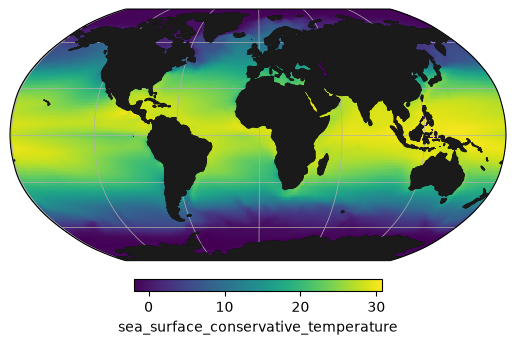

In [11]:
# -- Create a Figure with a Robinson projection -- #
projection = ccrs.Robinson(central_longitude=-1)

# Plot time-mean sea surface temperature [degC]:
(nemo["gridT/tos_con"]
 .mean(dim="time_counter")
 .geoplot(projection=projection)
)